# 7. Harris Edge & Corner Detection

## Table of Contents
1. [Libraries](#libraries)
2. [Color image to Grayscale conversion](#grayscale)
3. [Spatial derivative calculation](#spatial)
4. [Structure tensor setup](#tensor)
5. [Harris response calculation](#response)
6. [Find edges and corners using R](#find)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import matplotlib.pyplot as plt
from scipy import signal as sig
import numpy as np
from scipy.ndimage import convolve

## 1. Color to Grayscale <a class="anchor" id="grayscale" ></a>

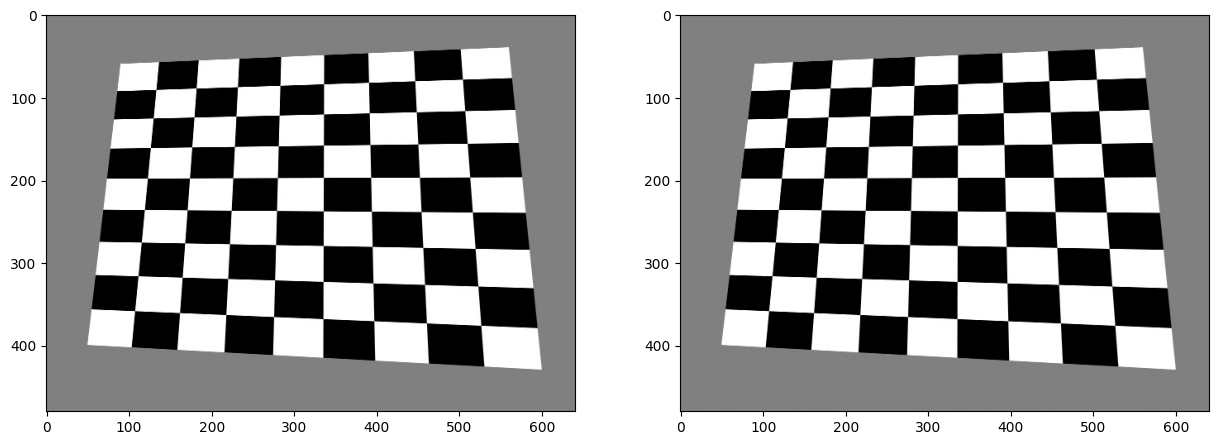

In [2]:
img = cv2.imread('data/chessboard.jpg')
img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")

## 2. Spatial derivative calculation <a class="anchor" id="spatial" ></a>

In [3]:
def gradient_x(imggray):
    ##Sobel operator kernels.
    kernel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
    return sig.convolve2d(imggray, kernel_x, mode='same')

def gradient_y(imggray):
    kernel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    return sig.convolve2d(imggray, kernel_y, mode='same')

I_x = gradient_x(img_gray)
I_y = gradient_y(img_gray)

## 3. Structure tensor setup <a class="anchor" id="tensor" ></a>

In [4]:
def gaussian_kernel(size, sigma=1):
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g


Ixx = convolve(I_x**2, gaussian_kernel(3, 1))
Ixy = convolve(I_y*I_x, gaussian_kernel(3, 1))
Iyy = convolve(I_y**2, gaussian_kernel(3, 1))

## 4. Harris response calculation <a class="anchor" id="response" ></a>

In [5]:
k = 0.05

# determinant
detA = Ixx * Iyy - Ixy ** 2

# trace
traceA = Ixx + Iyy
    
harris_response = detA - k * traceA ** 2

In [6]:
img_gray.shape

(480, 640)

In [7]:
window_size = 3
offset = window_size//2
width, height = img_gray.shape

for y in range(offset, height-offset):
    for x in range(offset, width-offset):
        Sxx = np.sum(Ixx[y-offset:y+1+offset, x-offset:x+1+offset])
        Syy = np.sum(Iyy[y-offset:y+1+offset, x-offset:x+1+offset])
        Sxy = np.sum(Ixy[y-offset:y+1+offset, x-offset:x+1+offset])

In [8]:
#Find determinant and trace, use to get corner response
det = (Sxx * Syy) - (Sxy**2)
trace = Sxx + Syy
r = det - k*(trace**2)

## 5. Find edges and corners using R <a class="anchor" id="find" ></a>

In [9]:
img_copy_for_corners = np.copy(img)
img_copy_for_edges = np.copy(img)

for rowindex, response in enumerate(harris_response):
    for colindex, r in enumerate(response):
        if r > 0:
            # this is a corner
            img_copy_for_corners[rowindex, colindex] = [255,0,0]
        elif r < 0:
            # this is an edge
            img_copy_for_edges[rowindex, colindex] = [0,255,0]

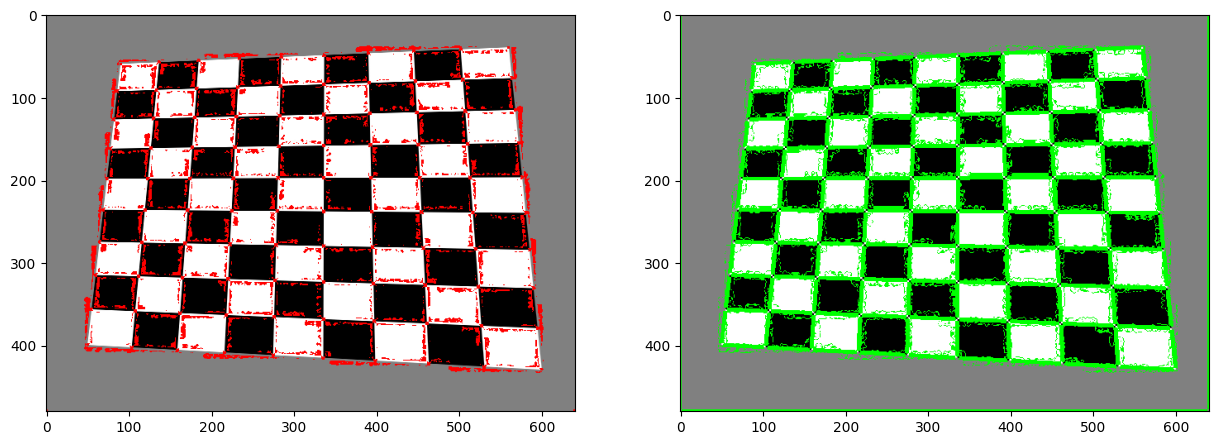

In [10]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_copy_for_corners, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_copy_for_edges, cmap="gray")

# Experimentos: el detector de Harris bajo distintas condiciones

La actividad pide probar el detector con un objeto fotografiado bajo **distinta iluminación** y **distintos ángulos**. Como aquí no se dispone de fotos propias de cada condición, se parte de una fotografía real de un letrero (CC0, ver `LICENCIAS.md`)
y se generan las demás vistas de forma **controlada**: los cambios de iluminación se simulan con brillo, gamma y ruido, y los de ángulo con la homografía exacta de un giro del plano del objeto, de la cámara o de la escala (`puntos.py`).
Así se conoce la verdad y se puede medir la **repetibilidad**: de las esquinas detectadas en la imagen original, qué fracción reaparece (a ≤ 3 px) en la imagen transformada. Si se dispone de fotos propias, basta con reemplazar `data/letrero.jpg` y cargar cada toma como una condición adicional.

Contenido: [1. Condiciones](#cond) · [2. Parámetros de Harris](#param) · [3. Hallazgos](#hall)

In [11]:
import numpy as np, cv2, matplotlib.pyplot as plt
import puntos as P
plt.rcParams.update({"font.size": 9})

objeto = cv2.imread("data/letrero.jpg")
h, w = objeto.shape[:2]
gris0 = P.gris(objeto)
FOCO = 650
I = np.eye(3)
def rot(**kw): return P.homografia_rotacion(w, h, FOCO, **kw)

condiciones = {
    "original":                         (I, {}),
    "poca luz (×0.3)":                  (I, dict(brillo=0.3)),
    "sobreexpuesta (γ=0.5, ×1.5)":      (I, dict(gamma=0.5, brillo=1.5)),
    "bajo contraste + ruido":           (I, dict(brillo=0.45, offset=70, ruido=8)),
    "plano girado 20°":                 (P.homografia_plano(w, h, FOCO, 20), {}),
    "plano girado 40°":                 (P.homografia_plano(w, h, FOCO, 40), {}),
    "plano girado 60°":                 (P.homografia_plano(w, h, FOCO, 60), {}),
    "giro 30° (roll)":                  (rot(roll=30), {}),
    "escala 0.6×":                      (P.homografia_rotacion(w, h, FOCO, escala=0.6), {}),
    "plano 40° + poca luz":             (P.homografia_plano(w, h, FOCO, 40), dict(brillo=0.3)),
}
vistas = {n: P.vista(objeto, H, **kw) for n, (H, kw) in condiciones.items()}
print(f"Imagen del objeto: {w}×{h} px; esquinas de referencia: {len(P.detectar_harris(gris0, n=300))}")

Imagen del objeto: 470×500 px; esquinas de referencia: 241


<a id="cond"></a>
## 1. Repetibilidad de Harris según la condición

Se toman las 300 esquinas más fuertes de la imagen original y de cada vista (Harris con ventana de 3 px, apertura de Sobel 3 y `k = 0.04`), y se mide qué fracción de las esquinas de la original que siguen dentro de la vista reaparecen a ≤ 3 px.

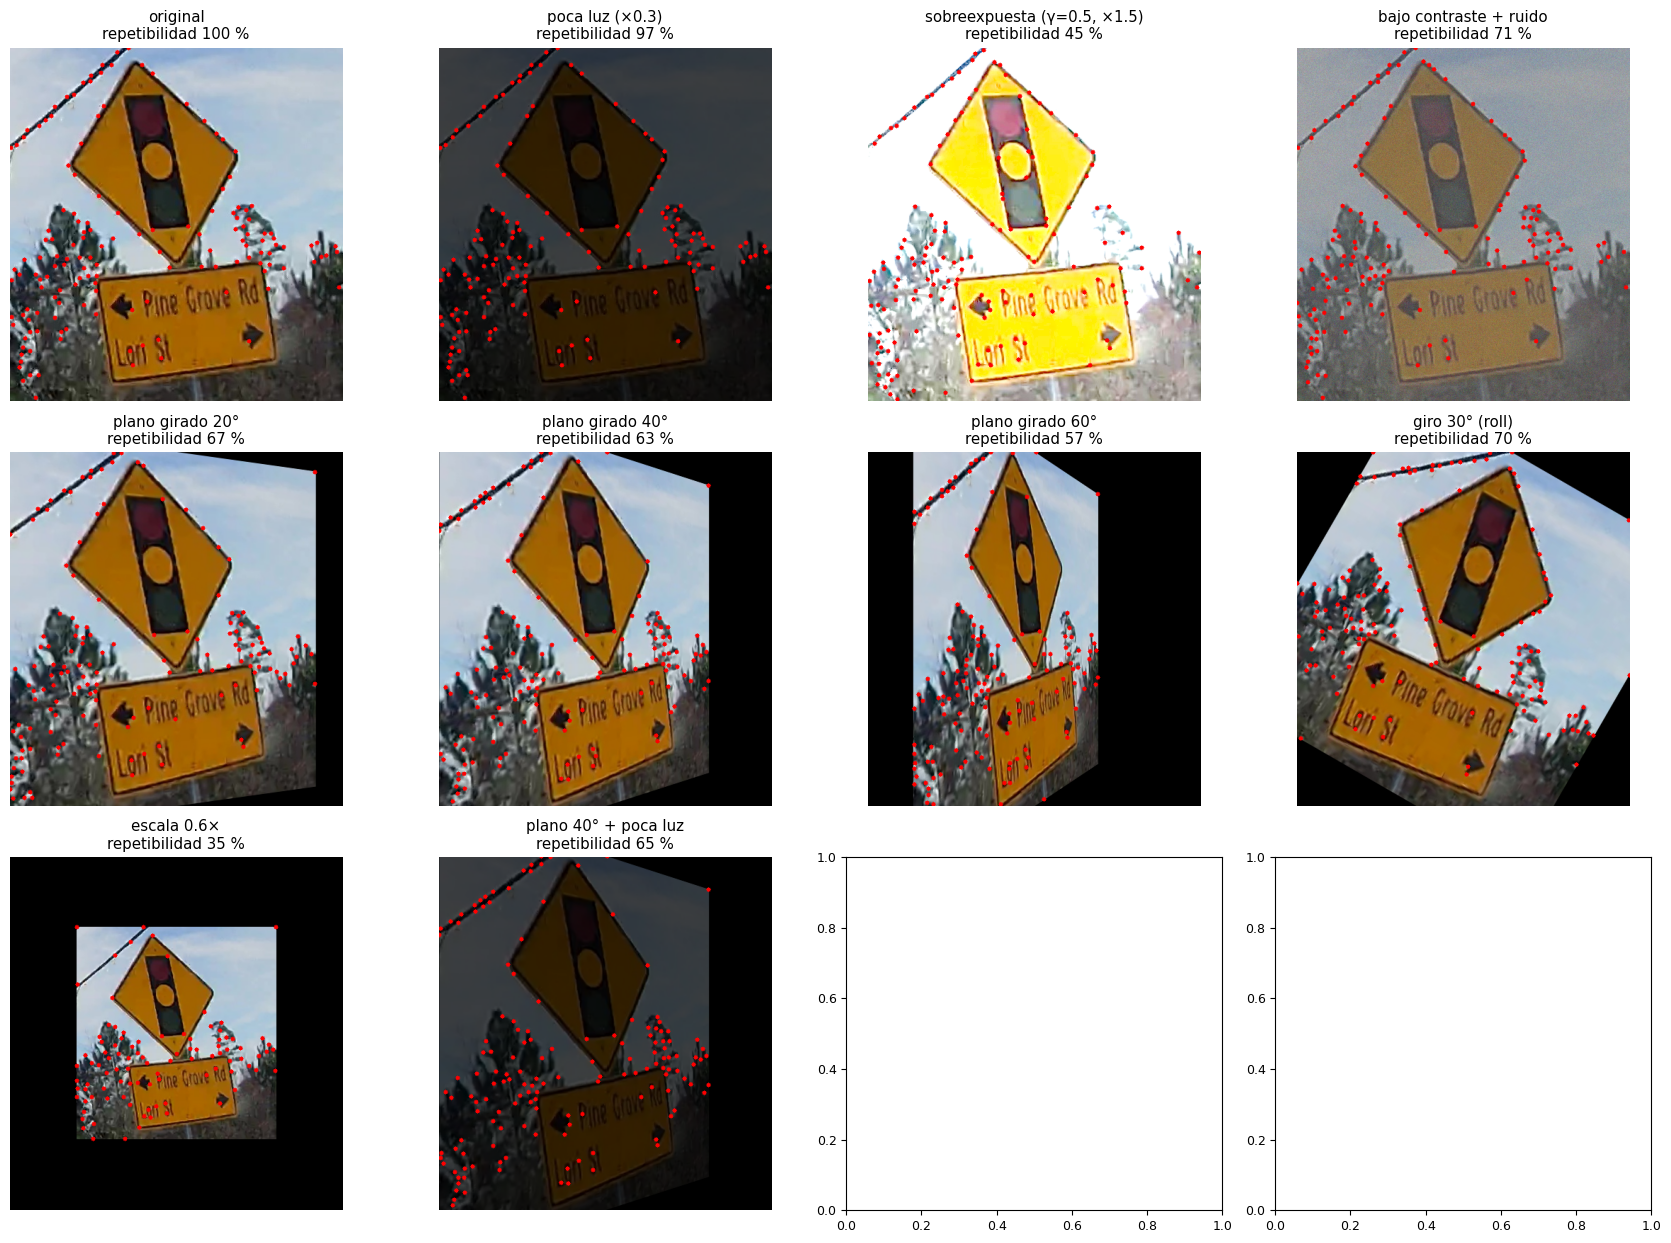

condición                         esquinas  visibles  repetibilidad %
original                               241       241            100.0
poca luz (×0.3)                        242       241             96.7
sobreexpuesta (γ=0.5, ×1.5)            251       241             44.8
bajo contraste + ruido                 300       241             71.0
plano girado 20°                       184       227             67.4
plano girado 40°                       183       231             62.8
plano girado 60°                       169       226             56.6
giro 30° (roll)                        182       219             69.9
escala 0.6×                             97       241             34.9
plano 40° + poca luz                   189       231             64.9


In [12]:
k0 = P.detectar_harris(gris0, n=300)
filas = []
fig, ejes = plt.subplots(3, 4, figsize=(17, 12.5))
for a, (nombre, (H, kw)) in zip(ejes.ravel(), condiciones.items()):
    v = vistas[nombre]; k1 = P.detectar_harris(P.gris(v), n=300)
    rep, visibles = P.repetibilidad(k0, k1, H, v.shape, 3.0)
    filas.append((nombre, len(k1), visibles, rep * 100))
    vis = v.copy()
    for kp in k1[:150]: cv2.circle(vis, (int(kp.pt[0]), int(kp.pt[1])), 3, (0, 0, 255), -1)
    a.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); a.set_title(f"{nombre}\nrepetibilidad {rep*100:.0f} %"); a.axis("off")
plt.tight_layout(); plt.show()
print(f"{'condición':32s} {'esquinas':>9s} {'visibles':>9s} {'repetibilidad %':>16s}")
for n, k, vs, r in filas: print(f"{n:32s} {k:9d} {vs:9d} {r:16.1f}")

<a id="param"></a>
## 2. Efecto de los parámetros del detector

La respuesta de Harris depende del tamaño de la ventana del tensor de estructura (`blockSize`) y del parámetro `k`. Se mide la repetibilidad en tres condiciones difíciles y el número de esquinas con respuesta mayor al 1 % del máximo.

In [13]:
dif = {"poca luz (×0.3)": (I, dict(brillo=0.3)), "plano girado 40°": (P.homografia_plano(w, h, FOCO, 40), {}), "giro 30° (roll)": (rot(roll=30), {}), "escala 0.6×": (P.homografia_rotacion(w, h, FOCO, escala=0.6), {})}
print(f"{'blockSize':>9s} {'k':>5s} {'esquinas orig.':>15s} " + " ".join(f"{n[:16]:>17s}" for n in dif))
for bloque in (2, 3, 5, 7):
    for kk in (0.04, 0.06):
        k0b = P.detectar_harris(gris0, n=300, bloque=bloque, k=kk)
        total = len(P.detectar_harris(gris0, n=100000, bloque=bloque, k=kk))
        fila = []
        for n, (H, kw) in dif.items():
            v = P.vista(objeto, H, **kw); k1 = P.detectar_harris(P.gris(v), n=300, bloque=bloque, k=kk)
            fila.append(P.repetibilidad(k0b, k1, H, v.shape, 3.0)[0] * 100)
        print(f"{bloque:9d} {kk:5.2f} {total:15d} " + " ".join(f"{x:16.1f}%" for x in fila))

blockSize     k  esquinas orig.   poca luz (×0.3)  plano girado 40°   giro 30° (roll)       escala 0.6×
        2  0.04             212             94.3%             73.9%             63.2%             39.2%
        2  0.06             210             98.1%             71.4%             60.3%             35.2%
        3  0.04             241             96.7%             62.8%             69.9%             34.9%
        3  0.06             233             95.7%             60.5%             65.6%             34.8%
        5  0.04             230             98.3%             68.5%             74.6%             35.7%


        5  0.06             224             98.7%             63.8%             70.3%             34.8%
        7  0.04             201             98.0%             67.9%             77.5%             32.3%
        7  0.06             191             97.4%             68.0%             77.4%             34.6%


<a id="hall"></a>
## 3. Hallazgos


**Iluminación.**
- Harris resiste bien los cambios de brillo lineales: con la luz reducida a ×0.3 la repetibilidad es de **96.7 %** (241 esquinas visibles y 242 detectadas). Un cambio de brillo multiplica los gradientes, pero no mueve el lugar donde la respuesta es máxima, y al quedarse con las 300 esquinas más fuertes el umbral se ajusta solo.
- Lo que sí lo daña es lo **no lineal**: con la imagen sobreexpuesta (γ=0.5, ×1.5) la repetibilidad cae a **44.8 %**, porque las luces se saturan (el letrero es de un amarillo brillante) y las esquinas de las zonas saturadas desaparecen; con bajo contraste y ruido llega a 71.0 % y se detectan 300 esquinas (el límite), muchas de ellas espurias.

**Ángulo.**
- Al girar el plano del objeto (escorzo) la repetibilidad baja de forma gradual: **67.4 % (20°), 62.8 % (40°) y 56.6 % (60°)**. Una esquina deja de tener el mismo aspecto cuando la vecindad se deforma. Con poca luz añadida (40° + ×0.3) es de 64.9 %, es decir, la luz influye mucho menos que el ángulo.
- Con un giro de 30° en el plano de la imagen la repetibilidad es de 69.9 %. En teoría Harris es invariante a rotación (el determinante y la traza del tensor de estructura no cambian al girar), así que la pérdida se debe al remuestreo con interpolación, a que 22 de las 241 esquinas salen del encuadre y a que la posición se mide a ±3 px.
- Con una escala de 0.6× cae a **34.9 %**: Harris **no es invariante a la escala**. Al reducir la imagen, una esquina se convierte en una curva suave dentro de la misma ventana. Esa es la razón de que SIFT trabaje en un espacio de escalas.

**Parámetros.** Aumentar `blockSize` mejora la repetibilidad frente al giro (63.2 % con 2, 69.9 % con 3, 74.6 % con 5 y 77.5 % con 7, con k = 0.04) y algo frente a la poca luz (94.3 % → 98.0 %), pero reduce el número de esquinas totales (212 → 201) y suaviza su localización. `k` (0.04 frente a 0.06) tiene un efecto pequeño y sin patrón consistente (diferencias de unos pocos puntos). Frente a la escala ningún ajuste ayuda (32–39 %).

**Limitación.** Las vistas son sintéticas a partir de una sola fotografía (sin paralaje, sombras ni reflejos reales). Con fotos propias del mismo objeto bajo el sol y en penumbra, y desde varios ángulos, se espera un comportamiento similar, con las diferencias que traigan las sombras y los reflejos.


## Referencias

- Harris, C., & Stephens, M. (1988). A combined corner and edge detector. En *Proceedings of the 4th Alvey Vision Conference* (pp. 147–151). Alvey Vision Club.
- Schmid, C., Mohr, R., & Bauckhage, C. (2000). Evaluation of interest point detectors. *International Journal of Computer Vision, 37*(2), 151–172. https://doi.org/10.1023/A:1008199403446
- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson.
- Bradski, G. (2000). The OpenCV library. *Dr. Dobb's Journal of Software Tools, 25*(11), 120–123.
- Imágenes: ver `LICENCIAS.md` (Wikimedia Commons, M. Rivera, CC0). El tablero `chessboard.jpg` se genera por código.